# Exploratary Data Analysis

## Setup and Data Loading

### Importing Required Libraries and Path Configuration

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

# --- Path Setup ---
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# --- Import Custom Scripts ---
from scripts import utils

# --- Configure Visualization Style ---
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### Loading Data

In [2]:
file_path = "../data/raw_data.csv"
df_raw = utils.load_data(file_path)
df = df_raw.copy()

Data loaded successfully.


## First Look

### Preview of the Data

In [3]:
print("First 5 Rows:")
display(df.head())
print("\nLast 5 Rows:")
display(df.tail())

First 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,537359,22469,HEART OF WICKER SMALL,22,2024-01-26 13:12,11.32,12813.0,Netherlands
1,538693,71053,WHITE METAL LANTERN,46,2024-12-06 23:36,19.71,14324.0,United Kingdom
2,537160,22086,PAPER CHAIN KIT 50'S CHRISTMAS,4,2024-04-26 05:36,4.64,16563.0,United Kingdom
3,538035,22960,JAM MAKING SET WITH JARS,1,2024-02-20 03:50,16.74,16806.0,Switzerland
4,536671,21931,JUMBO STORAGE BAG SUKI,45,2024-05-28 10:54,4.47,15363.0,United Kingdom



Last 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
10948,537832,22386,JUMBO BAG PINK POLKADOT,29,2024-07-23 14:54,14.86,18139.0,United Kingdom
10949,537706,21730,GLASS STAR FROSTED T-LIGHT HOLDER,22,2024-12-01 05:52,11.69,16745.0,EIRE
10950,537751,84879,ASSORTED COLOUR BIRD ORNAMENT,31,2024-07-03 12:00,20.72,16610.0,EIRE
10951,536603,22386,JUMBO BAG PINK POLKADOT,17,2024-10-11 22:25,17.19,16770.0,United Kingdom
10952,538227,21931,JUMBO STORAGE BAG SUKI,9,2024-05-07 04:31,8.26,NaN,United Kingdom


<b>Action Plan: </b>
* CustomerID column is float but it should be int.  

###  Data Structure and Types

In [4]:
print("\nData Structure:")
df.info()


Data Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10953 entries, 0 to 10952
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    10953 non-null  object 
 1   StockCode    10953 non-null  object 
 2   Description  10953 non-null  object 
 3   Quantity     10953 non-null  int64  
 4   InvoiceDate  10953 non-null  object 
 5   UnitPrice    10953 non-null  object 
 6   CustomerID   10429 non-null  float64
 7   Country      10953 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 684.7+ KB


<b>Action Plan:</b>
* UnitPrice column should be float/int not object.
* CustomerID column has missing values. 
* CustomerID should be object.

### Descriptive Statics of Data

In [5]:
print("\nData Description:")
display(df.describe().T)


Data Description:


,count,mean,std,min,25%,50%,75%,max
Quantity,10953.0,23.400803,15.902324,-47.0,12.0,24.0,37.0,48.0
CustomerID,10429.0,15319.989932,1728.550652,12347.0,13807.0,15328.0,16782.0,18287.0


<b>Action Plan: </b>  
* Quantity column has negative values. It can be return or wrong formatting.

##  Deep Dive into Data Quality Issues

### Missing Values

InvoiceNo      0.000000
StockCode      0.000000
Description    0.000000
Quantity       0.000000
InvoiceDate    0.000000
UnitPrice      0.000000
CustomerID     4.784077
Country        0.000000
dtype: float64


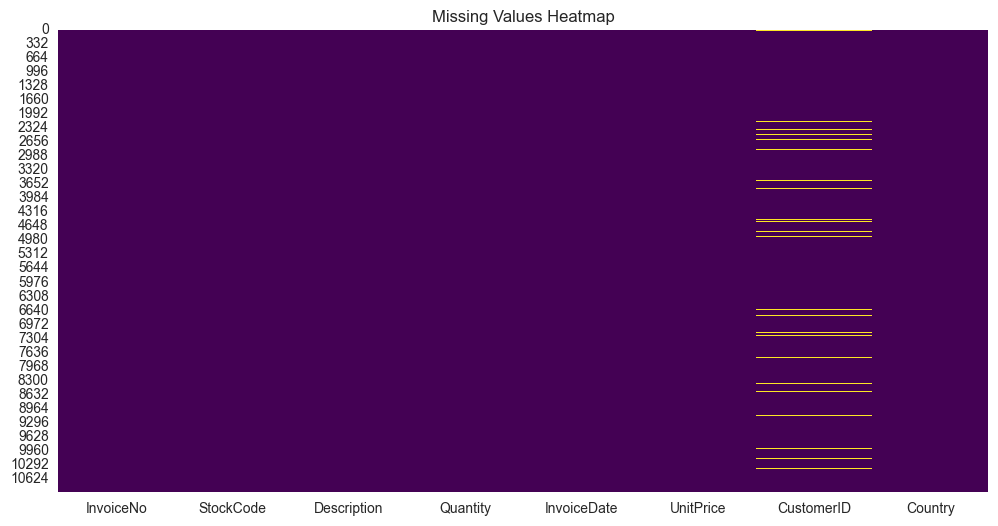

In [6]:
# Calculate percentage of missing values
missing_percentage = df.isnull().sum() / len(df) * 100
print(missing_percentage)

# Visualize missing values
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


<b>Action Plan: </b> Rows with missing CustomerID are not useful for customer segmentation and should be dropped.

###  Duplicate Records

In [7]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 586


<b> Action Plan:</b> Duplicated rows should be dropout.

# Data Cleaning

## Issues:
* CustomerID  - Wrong Data Type
* UnitPrice   - Wrong Data Type
* CustomerID  - Missing Values
* Duplicated rows
* Quantity    - Negative Values

## Should be check
* Country
* InvoiceDate

In [8]:
# Dropping duplicates and missing values
df = df.drop_duplicates()
df = df.dropna()

In [9]:
# changing the data type of 'CustomerID' to object
df['CustomerID'] = df['CustomerID'].astype(int)

In [10]:
# There is a few '£'  symbols in the 'UnitPrice' column
# We need to remove these symbols and convert the column to numeric

df['UnitPrice'] = df['UnitPrice'].replace({'£': ''}, regex=True).astype(float)


In [11]:
df['Country'].value_counts()

Country
United Kingdom    8405
France             311
Germany            279
EIRE               180
Australia          110
Norway             107
Belgium            101
Portugal           100
Netherlands         95
Spain               93
Switzerland         91
Name: count, dtype: int64

Country column looks clear.

In [12]:
# Convert 'InvoiceDate' to datetime
# But we need to ensure the format is consistent

date_series = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Find which rows are problematic
is_nat_mask = date_series.isnull()

# Use this mask to select problematic rows from the original DataFrame
problematic_rows = df[is_nat_mask]

# Check the first few rows of problematic data
print(f"Count of problematic rows: {len(problematic_rows)}")
print("Examples of problematic rows:")
print(problematic_rows.head(10))

# Types of problematic 'InvoiceDate' values:
print("\nTypes of problematic 'InvoiceDate' values:")
print(problematic_rows['InvoiceDate'].value_counts().head(10))

Count of problematic rows: 996
Examples of problematic rows:
    InvoiceNo StockCode                     Description  Quantity  \
22     538470    84406B  CREAM CUPID HEARTS COAT HANGER        35   
49     536845     22727        ALARM CLOCK BAKELIKE RED         4   
87     538030     84991     60 TEATIME FAIRY CAKE CASES        13   
92    C538836     84991     60 TEATIME FAIRY CAKE CASES       -13   
96     537687     71053             WHITE METAL LANTERN        47   
102    538846     22138    BAKING SET 9 PIECE RETROSPOT        39   
112    536783     84991     60 TEATIME FAIRY CAKE CASES         5   
122    537324     22138    BAKING SET 9 PIECE RETROSPOT        29   
127    536612     22469           HEART OF WICKER SMALL        44   
133    537617     21931          JUMBO STORAGE BAG SUKI        11   

        InvoiceDate  UnitPrice  CustomerID         Country  
22   06/26/24 21:02      17.06       14315  United Kingdom  
49   04/12/24 15:37      22.82       15588  United Kingdo

In [15]:
# Ensure 'InvoiceDate' is datetime and drop rows with invalid dates
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df = df[df['InvoiceDate'].notna()]

## Last Check

In [17]:
print("First 5 Rows:")
display(df.head())
print("\nLast 5 Rows:")
display(df.tail())

First 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,537359,22469,HEART OF WICKER SMALL,22,2024-01-26 13:12:00,11.32,12813,Netherlands
1,538693,71053,WHITE METAL LANTERN,46,2024-12-06 23:36:00,19.71,14324,United Kingdom
2,537160,22086,PAPER CHAIN KIT 50'S CHRISTMAS,4,2024-04-26 05:36:00,4.64,16563,United Kingdom
3,538035,22960,JAM MAKING SET WITH JARS,1,2024-02-20 03:50:00,16.74,16806,Switzerland
4,536671,21931,JUMBO STORAGE BAG SUKI,45,2024-05-28 10:54:00,4.47,15363,United Kingdom



Last 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
10947,537968,21485,RETROSPOT HEART HOT WATER BOTTLE,48,2024-10-13 17:00:00,6.98,17392,United Kingdom
10948,537832,22386,JUMBO BAG PINK POLKADOT,29,2024-07-23 14:54:00,14.86,18139,United Kingdom
10949,537706,21730,GLASS STAR FROSTED T-LIGHT HOLDER,22,2024-12-01 05:52:00,11.69,16745,EIRE
10950,537751,84879,ASSORTED COLOUR BIRD ORNAMENT,31,2024-07-03 12:00:00,20.72,16610,EIRE
10951,536603,22386,JUMBO BAG PINK POLKADOT,17,2024-10-11 22:25:00,17.19,16770,United Kingdom


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8876 entries, 0 to 10951
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    8876 non-null   object        
 1   StockCode    8876 non-null   object        
 2   Description  8876 non-null   object        
 3   Quantity     8876 non-null   int64         
 4   InvoiceDate  8876 non-null   datetime64[ns]
 5   UnitPrice    8876 non-null   float64       
 6   CustomerID   8876 non-null   int64         
 7   Country      8876 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 624.1+ KB


In [18]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,8876.0,23.368184,-47.0,12.0,24.0,36.0,48.0,15.781025
InvoiceDate,8876,2024-07-03 18:12:02.778278656,2024-01-01 00:12:00,2024-04-07 00:31:00,2024-06-30 18:03:00,2024-10-05 23:42:45,2024-12-30 23:33:00,NaN
UnitPrice,8876.0,12.642016,0.5,6.44,12.635,18.69,24.99,7.021956
CustomerID,8876.0,15335.677332,12347.0,13817.0,15355.0,16808.0,18287.0,1730.233509


In [20]:
# Saving the cleaned DataFrame
cleaned_file_path = "../data/cleaned_data.csv"
df.to_csv(cleaned_file_path, index=False)